# Logistic Regression: Predict Gender from Height and Weight

**Goal:** train a logistic regression classifier that predicts whether a person is male (`1`) or female (`0`) from their height and weight.

Steps:
1. Load and explore the data
2. Split into training and test sets
3. Fit the model
4. Inspect the learned parameters (theta)
5. Evaluate on unseen data and make new predictions
6. Visualise the decision boundary

## 1. Load the data

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set()

file_name = "heights_weights.csv"
df = pd.read_csv(file_name)
df.head()

,Height,Weight,Male
0,73.847017,241.893563,1
1,68.781904,162.310473,1
2,74.110105,212.740856,1
3,71.730978,220.042470,1
4,69.881796,206.349801,1


In [2]:
print("Shape:", df.shape)
print()
print(df.isnull().sum())
print()
df.describe()

Shape: (10000, 3)

Height    0
Weight    0
Male      0
dtype: int64



,Height,Weight,Male
count,10000.000000,10000.000000,10000.000000
mean,66.367560,161.440357,0.500000
std,3.847528,32.108439,0.500025
min,54.263133,64.700127,0.000000
25%,63.505620,135.818051,0.000000
50%,66.318070,161.212928,0.500000
75%,69.174262,187.169525,1.000000
max,78.998742,269.989699,1.000000


In [3]:
# Class balance (1 = Male, 0 = Female)
df["Male"].value_counts()

Male
1    5000
0    5000
Name: count, dtype: int64

## 2. Visualise the data

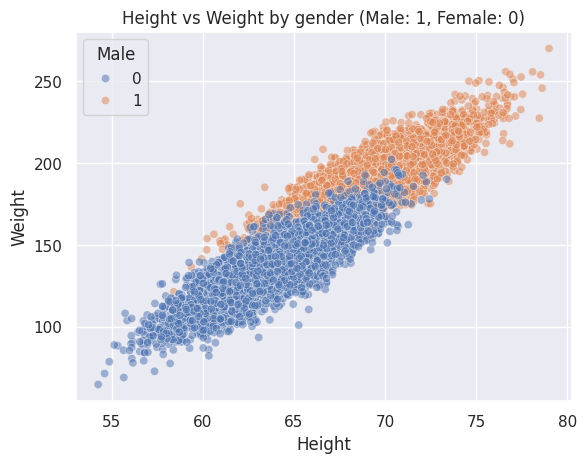

In [4]:
ax = sns.scatterplot(x="Height", y="Weight", hue="Male", data=df, alpha=0.5)
ax.set_title("Height vs Weight by gender (Male: 1, Female: 0)")
plt.show()

The two classes overlap, but males tend to be taller and heavier. A straight line can separate them reasonably well, which is what logistic regression learns.

## 3. Prepare training and test data

In [5]:
# Features: Height, Weight  |  Target: Male
x = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

# 70% train, 30% test
X_train, X_test, Y_train, Y_test = train_test_split(
    x, y, test_size=0.3, random_state=0
)

print("Train size:", X_train.shape[0])
print("Test size: ", X_test.shape[0])

Train size: 7000
Test size:  3000


## 4. Fit the logistic regression model

`C=1e40` makes the regularisation strength effectively zero, so this is plain (unregularised) logistic regression, matching the classic textbook formulation.

In [6]:
clf = linear_model.LogisticRegression(C=1e40, solver="newton-cg")
fitted_model = clf.fit(X_train, Y_train)

## 5. Model parameters (theta)

The model learns three values:

$$h_\theta(x) = \frac{1}{1 + e^{-(\theta_0 + \theta_1 \cdot \text{Height} + \theta_2 \cdot \text{Weight})}}$$

- $\theta_0$ is the intercept
- $\theta_1$ is the coefficient for height
- $\theta_2$ is the coefficient for weight

In [7]:
print("theta_0 (intercept):", fitted_model.intercept_)
print("theta_1, theta_2 (coefficients):", fitted_model.coef_)

theta_0 (intercept): [-0.01043891]
theta_1, theta_2 (coefficients): [[-0.49559171  0.20352939]]


## 6. Evaluate on the test set

In [8]:
Y_pred = clf.predict(X_test)

print("Accuracy: {0:.2f}%".format(100 * accuracy_score(Y_test, Y_pred)))
print()
print("Confusion matrix (rows = actual, columns = predicted):")
print(confusion_matrix(Y_test, Y_pred))
print()
print(classification_report(Y_test, Y_pred, target_names=["Female", "Male"]))

Accuracy: 91.87%

Confusion matrix (rows = actual, columns = predicted):
[[1385  104]
 [ 140 1371]]

              precision    recall  f1-score   support

      Female       0.91      0.93      0.92      1489
        Male       0.93      0.91      0.92      1511

    accuracy                           0.92      3000
   macro avg       0.92      0.92      0.92      3000
weighted avg       0.92      0.92      0.92      3000



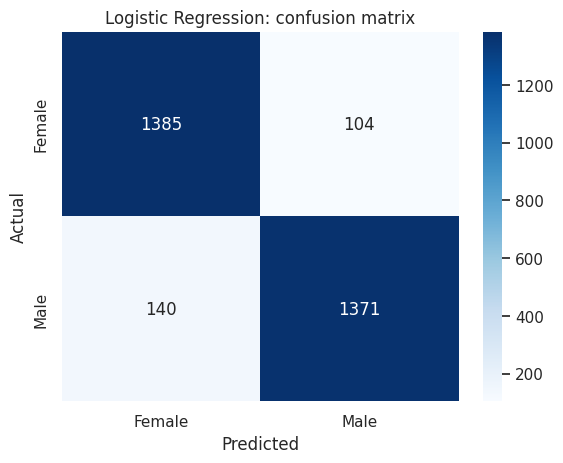

In [9]:
sns.heatmap(confusion_matrix(Y_test, Y_pred), annot=True, fmt="d", cmap="Blues",
            xticklabels=["Female", "Male"], yticklabels=["Female", "Male"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression: confusion matrix")
plt.show()

## 7. Predict for new people

In [10]:
# Two people's [height, weight]
new_data = [[74, 240], [80, 50]]

predictions = clf.predict(new_data)
probabilities = clf.predict_proba(new_data)

for i, pred in enumerate(predictions):
    result = "Male" if pred else "Female"
    print(f"Person {i+1} (height={new_data[i][0]}, weight={new_data[i][1]}) "
          f"-> {result}  (P(male) = {probabilities[i][1]:.3f})")

Person 1 (height=74, weight=240) -> Male  (P(male) = 1.000)
Person 2 (height=80, weight=50) -> Female  (P(male) = 0.000)


## 8. Decision boundary

The boundary is where $\theta_0 + \theta_1 \cdot \text{Height} + \theta_2 \cdot \text{Weight} = 0$, i.e. where the model is 50/50.

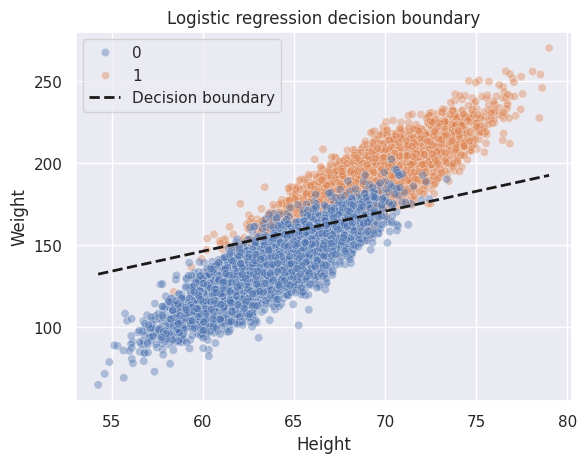

In [11]:
theta0 = fitted_model.intercept_[0]
theta1, theta2 = fitted_model.coef_[0]

heights = np.linspace(df["Height"].min(), df["Height"].max(), 100)
weights_boundary = -(theta0 + theta1 * heights) / theta2

ax = sns.scatterplot(x="Height", y="Weight", hue="Male", data=df, alpha=0.4)
ax.plot(heights, weights_boundary, "k--", linewidth=2, label="Decision boundary")
ax.set_ylim(df["Weight"].min() - 10, df["Weight"].max() + 10)
ax.set_title("Logistic regression decision boundary")
ax.legend()
plt.show()

## Summary

- Logistic regression outputs a probability, then thresholds it at 0.5 to choose a class.
- The decision boundary is a straight line in this 2-feature space.
- Compare the accuracy here with the SVM notebook, which uses the same data and split.